In [19]:
# importing the necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold


# loading the dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

print("Path to dataset files:", path)


# Load the dataset into a pandas DataFrame

df = pd.read_csv(path + '/customer_churn_dataset-training-master.csv')

Path to dataset files: C:\Users\Mveun\.cache\kagglehub\datasets\muhammadshahidazeem\customer-churn-dataset\versions\1


In [20]:
print("Data shape :" , df.shape) 
print("basic info about the dataset :")
print("-" * 80)
print(df.info())
print("-" * 80)
print("Statistical summary of the dataset :")
df.describe()

Data shape : (440833, 12)
basic info about the dataset :
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None
-------

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [21]:
df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


# Simple overviwe before cleaning 


the distribution of the column :  Age


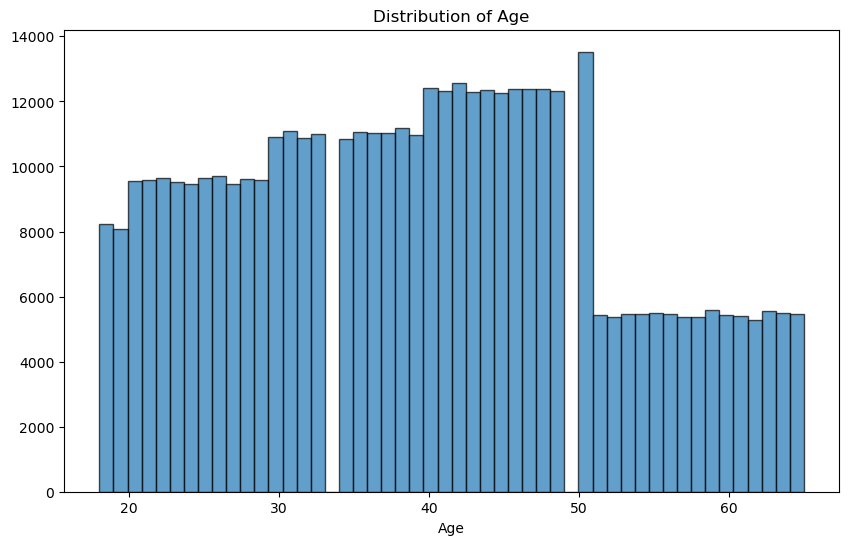

the distribution of the column :  Tenure


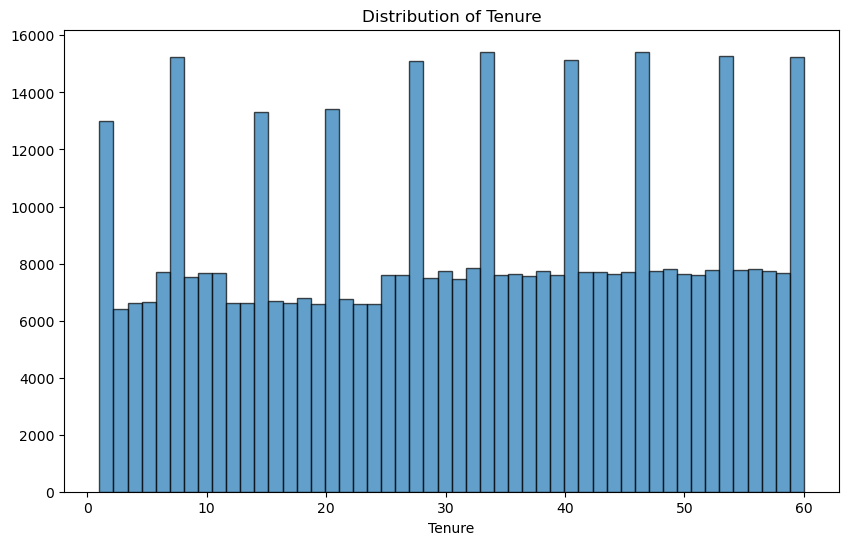

the distribution of the column :  Usage Frequency


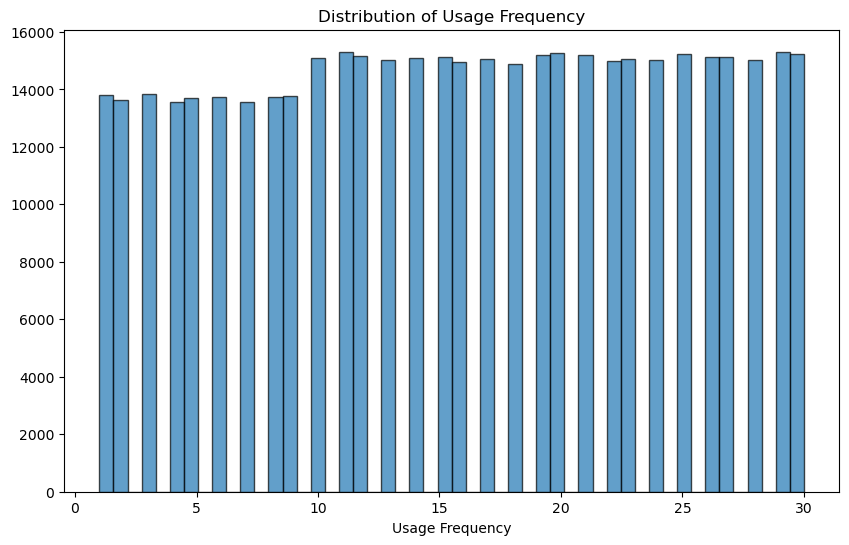

the distribution of the column :  Support Calls


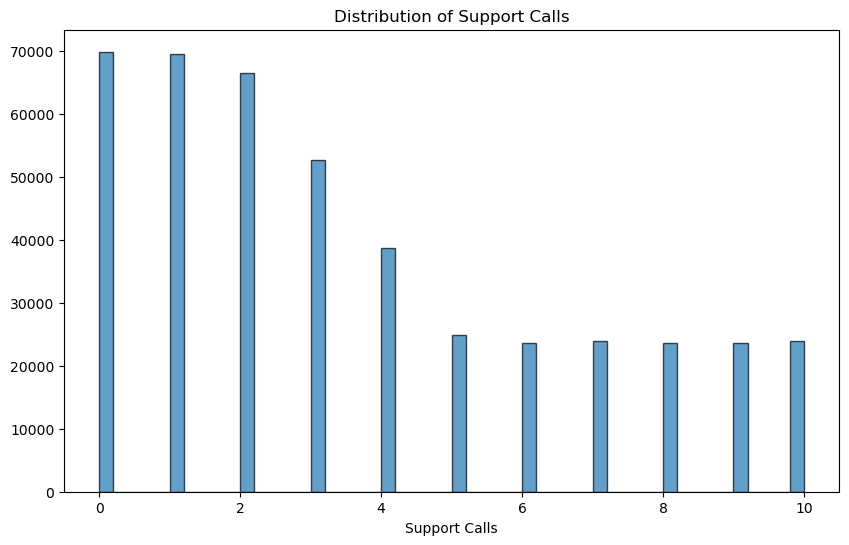

the distribution of the column :  Payment Delay


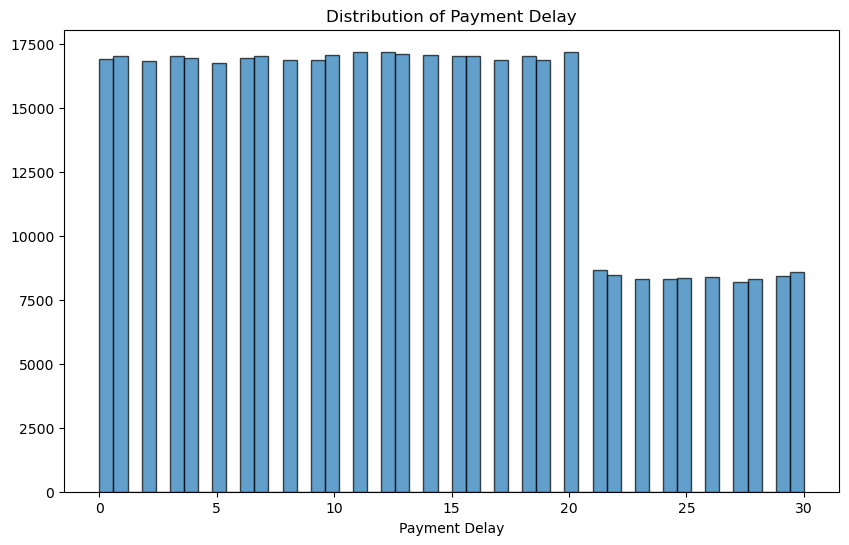

the distribution of the column :  Total Spend


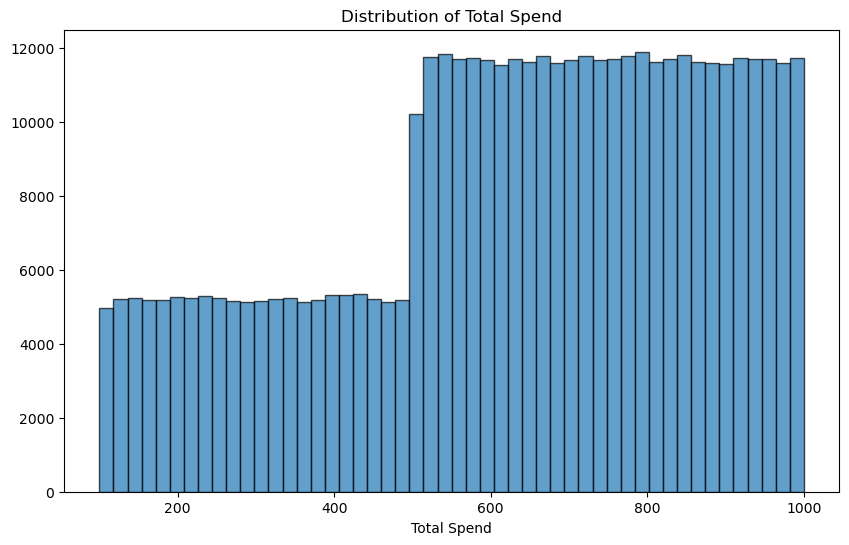

the distribution of the column :  Last Interaction


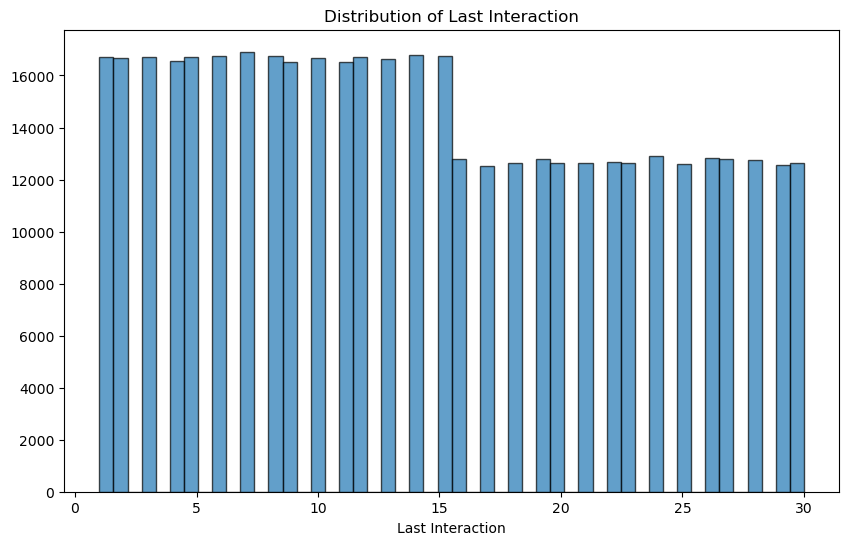

the distribution of the column :  Churn


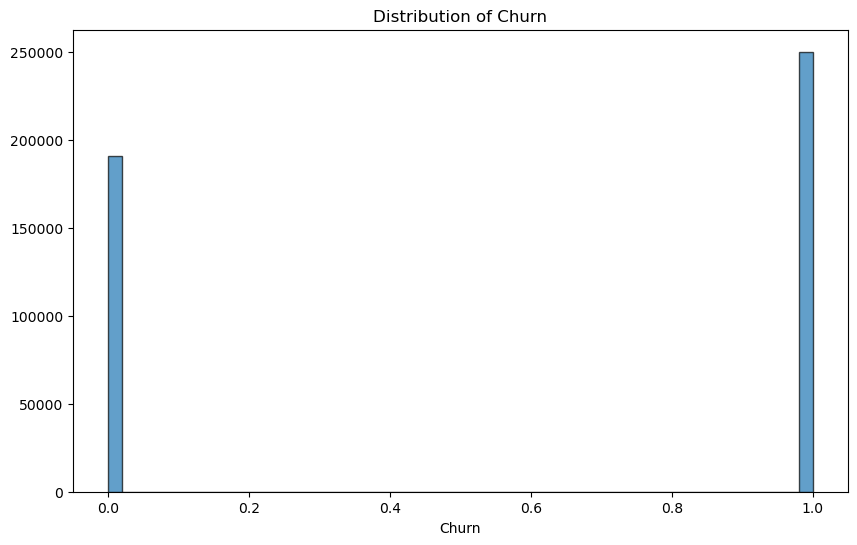

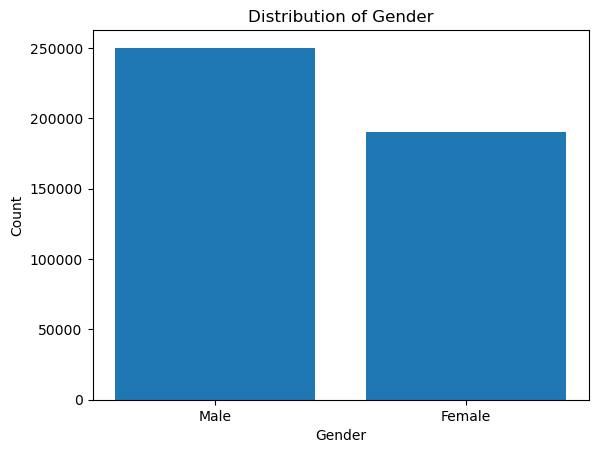

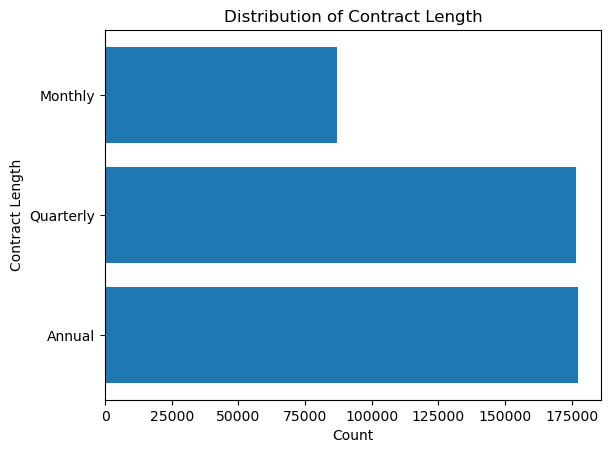

the distribution of the target variable :  Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


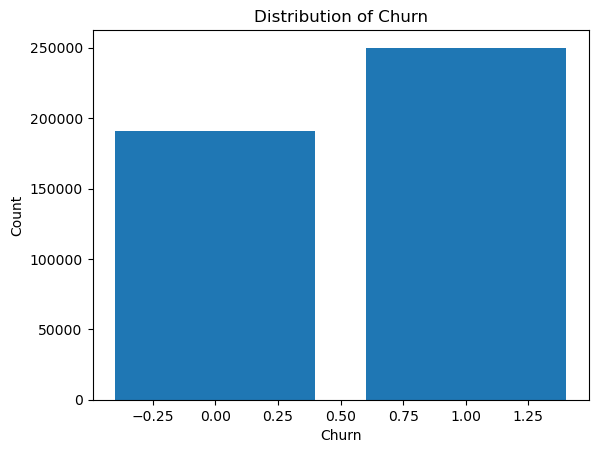

the description of the Subscription Type	 :  Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64


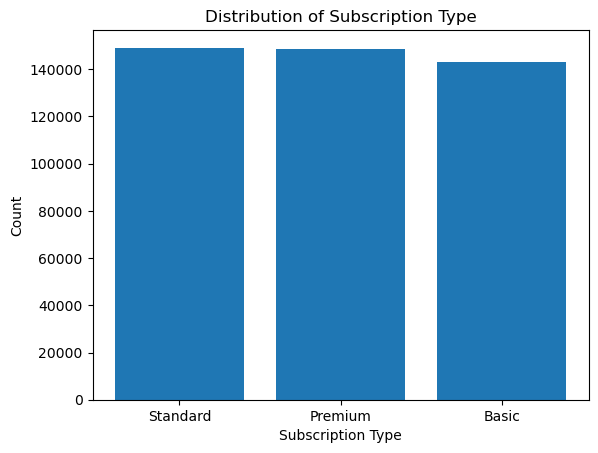

In [22]:
def data_overview(df) : 

    numeric_df = df.select_dtypes(include='number') 
    numeric_df.drop(columns=['CustomerID'], inplace=True)  
    for col in numeric_df.columns:  
        print("the distribution of the column : " , col)
        plt.figure(figsize=(10, 6))
        plt.hist(numeric_df[col], bins=50, edgecolor='k', alpha=0.7)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.show()
    
    plt.bar(df["Gender"].value_counts().index, df["Gender"].value_counts().values)
    plt.title("Distribution of Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.show()

    plt.barh(df["Contract Length"].value_counts().index, df["Contract Length"].value_counts().values)
    plt.title("Distribution of Contract Length")
    plt.xlabel("Count")
    plt.ylabel("Contract Length")
    plt.show()

    print("the distribution of the target variable : " , df["Churn"].value_counts())
    plt.bar(df["Churn"].value_counts().index, df["Churn"].value_counts().values)
    plt.title("Distribution of Churn")
    plt.xlabel("Churn")
    plt.ylabel("Count")
    plt.show()

    print("the description of the Subscription Type	 : " , df["Subscription Type"].value_counts())
    plt.bar(df["Subscription Type"].value_counts().index, df["Subscription Type"].value_counts().values)
    plt.title("Distribution of Subscription Type")
    plt.xlabel("Subscription Type")
    plt.ylabel("Count")
    plt.show()


    

data_overview(df)

# Data Cleaning 

In [ ]:
def Cleaning(df) : 
    df_clean = df.copy()

    df_clean.drop(columns=['CustomerID'], inplace=True)
    

    print("Number of missing values in each column :")
    print(df_clean.isnull().sum())
    print("-" * 80)

    print("Number of duplicate rows in the dataset :")
    print(df_clean.duplicated().sum())
    print("-" * 80)

    print("removing all the duplicate rows and missing values from the dataset")
    df_clean.drop_duplicates(inplace=True)
    df_clean.dropna(inplace=True)
    print("-" * 80)


    print("checkking for outliers in the numeric columns :")

    numeric_df = df_clean.select_dtypes(include='number')
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = numeric_df[(numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)]
        print(f"Number of outliers in column {col} : {outliers.shape[0]}")

        int_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Last Interaction', 'Total Spend', 'Churn']
    df_clean[int_cols] = df_clean[int_cols].astype(int)



        

        
    return df_clean
    

df_clean = Cleaning(df)

Number of missing values in each column :
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
--------------------------------------------------------------------------------
Number of duplicate rows in the dataset :
0
--------------------------------------------------------------------------------
removing all the duplicate rows and missing values from the dataset
--------------------------------------------------------------------------------
checkking for outliers in the numeric columns :
Number of outliers in column Age : 0
Number of outliers in column Tenure : 0
Number of outliers in column Usage Frequency : 0
Number of outliers in column Support Calls : 0
Number of outliers in column Payment Delay : 0
Number of outliers in column Total Spend : 0
Number of outliers in co

In [31]:
df_clean.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30,Female,39,14,5,18,Standard,Annual,932,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617,20,1


# EDA

EDA and analysis of the dataset : 
--------------------------------------------------------------------------------
Average spending by gender :
Gender
Female    613.132553
Male      645.214328
Name: Total Spend, dtype: float64
--------------------------------------------------------------------------------
Average spending by Subscription Type :
Subscription Type
Basic       628.407793
Premium     632.652363
Standard    632.857927
Name: Total Spend, dtype: float64


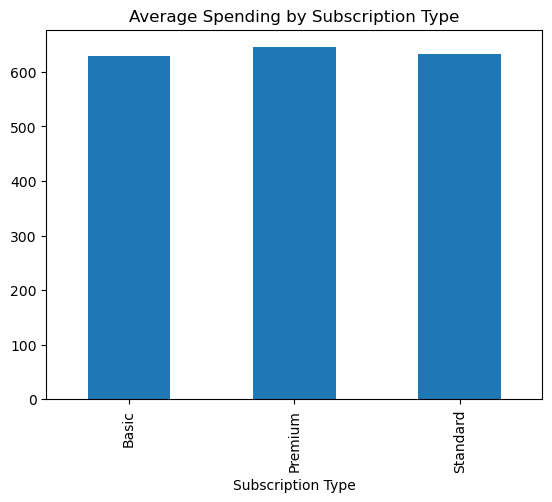

--------------------------------------------------------------------------------


In [49]:
print("EDA and analysis of the dataset : ")
print("-" * 80)

print("Average spending by gender :")
Gender_spend= df_clean.groupby("Gender")["Total Spend"].mean()
print(Gender_spend)
Gender_spend.plot(kind='bar')
plt.title("Average Spending by Gender")
print("-" * 80)

print("Average spending by Subscription Type :")
subs_spend = df_clean.groupby("Subscription Type")["Total Spend"].mean()
print(subs_spend)

subs_spend.plot(kind='bar')
plt.title("Average Spending by Subscription Type")
plt.show()
print("-" * 80)






# Preprocessing

In [25]:
def Data_preprocessing(df):
    df_pre = df_clean.copy()

    
X = df_pre.drop(columns=['Churn'])
y = df_pre['Churn']

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"K-Fold Cross Validation with {n_splits} folds")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(f"Fold {fold}:")
    print(f"  Train size: {len(X_train):,}  |  Val size: {len(X_val):,}")
    print(f"  Train churn rate: {y_train.mean():.4f}  |  Val churn rate: {y_val.mean():.4f}")

print("-" * 60)
print("Folds generated successfully. Use X_train/y_train and X_val/y_val inside the loop for model training.")

  

NameError: name 'df_pre' is not defined